## 1. Read the data

In [6]:
import pandas as pd

news = pd.read_csv('OnlineNewsPopularity.csv')
news.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


dataset loads into a pandas DataFrame with many columns
2. Plot sentiment vs. shares

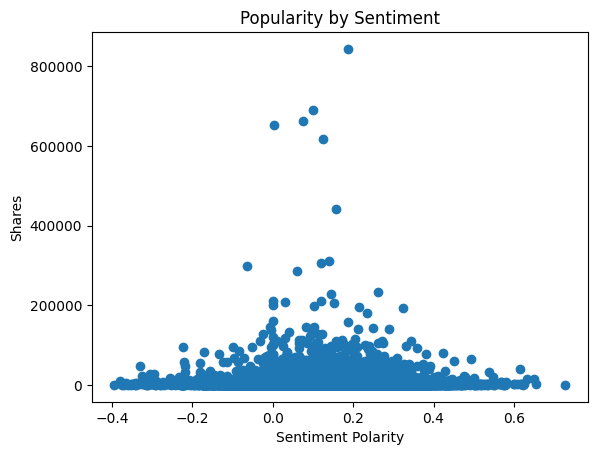

In [7]:
from matplotlib import pyplot as plt

plt.scatter(news[' global_sentiment_polarity'], news[' shares'])
plt.title('Popularity by Sentiment')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Shares')
plt.show()

the chapter checks wheater article sentiment seems related to popularity. the book says there is no strong visible linear relationship. The scatterplot should look widely dispersed, with no obvious straight-line trend.

3. Linear regression

In [8]:
from sklearn.linear_model import LinearRegression

x = news[' global_sentiment_polarity'].values.reshape(-1, 1)
y = news[' shares'].values.reshape(-1, 1)

regressor = LinearRegression()
regressor.fit(x, y)

print(regressor.coef_)
print(regressor.intercept_)

[[499.34840588]]
[3335.80329021]


the calues should be close to coeffiecient of 499.3 and an intercept of 3335.8 they can be different but should be very close
4. Plot the regression line

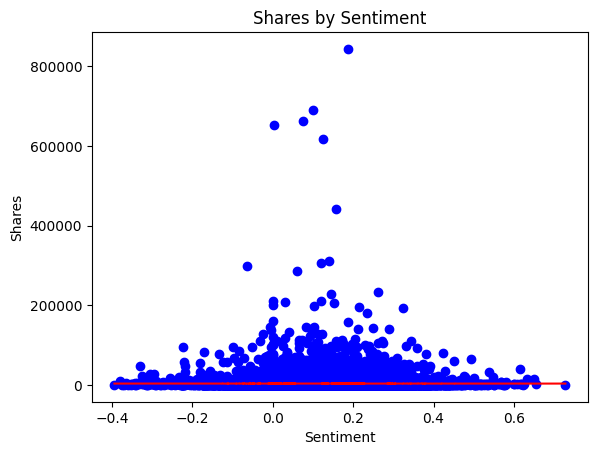

In [9]:
regline = regressor.predict(x)

plt.scatter(news[' global_sentiment_polarity'], news[' shares'], color='blue')
plt.plot(sorted(news[' global_sentiment_polarity'].tolist()), regline, 'r')
plt.title('Shares by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Shares')
plt.show()

the regression line should look fairly flat which matches the books point that linear regression is not a very helpful predictor here when using sentiment alone 5. Manual K-nearest neighbors

In [10]:
k = 15
newsentiment = 0.5

allsentiment = news[' global_sentiment_polarity'].tolist()
allshares = news[' shares'].tolist()

distances = [abs(x - newsentiment) for x in allsentiment]

import numpy as np
idx = np.argsort(distances)

print(idx[0:k])

[30230 29598 22546  7284 13035 19361 36029 30670 25556  6744 26473  7211
  9200 15198 31496]


this should print the index positions od the 15 closest articles in sentiment space.

In [11]:
nearbyshares = [allshares[i] for i in idx[0:k]]
print(np.mean(nearbyshares))

7344.466666666666


the chapter has a mean close to 7344.46666 for the 15 nearest neighbors whe newsentiment = 0.5


6. k=NN using sklearn

In [12]:
from sklearn.neighbors import KNeighborsRegressor

x = np.array(allsentiment).reshape(-1, 1)
y = np.array(allshares)

knnregressor = KNeighborsRegressor(n_neighbors=15)
knnregressor.fit(x, y)

print(knnregressor.predict(np.array([newsentiment]).reshape(1, -1)))

[7344.46666667]


this should match the manual k-nn result arounf 7344.466

7. Compare multiple supervised learning models

In [13]:
# linear regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(np.array(allsentiment).reshape(-1, 1), np.array(allshares))
print(regressor.predict(np.array([newsentiment]).reshape(1, -1)))

# knn
from sklearn.neighbors import KNeighborsRegressor
knnregressor = KNeighborsRegressor(n_neighbors=15)
knnregressor.fit(np.array(allsentiment).reshape(-1, 1), np.array(allshares))
print(knnregressor.predict(np.array([newsentiment]).reshape(1, -1)))

# decision tree
from sklearn.tree import DecisionTreeRegressor
dtregressor = DecisionTreeRegressor(max_depth=3)
dtregressor.fit(np.array(allsentiment).reshape(-1, 1), np.array(allshares))
print(dtregressor.predict(np.array([newsentiment]).reshape(1, -1)))

# random forest
from sklearn.ensemble import RandomForestRegressor
rfregressor = RandomForestRegressor()
rfregressor.fit(np.array(allsentiment).reshape(-1, 1), np.array(allshares))
print(rfregressor.predict(np.array([newsentiment]).reshape(1, -1)))

# neural network
from sklearn.neural_network import MLPRegressor
nnregressor = MLPRegressor()
nnregressor.fit(np.array(allsentiment).reshape(-1, 1), np.array(allshares))
print(nnregressor.predict(np.array([newsentiment]).reshape(1, -1)))

[3585.47749315]
[7344.46666667]
[3978.70776621]
[4933.03991991]
[4000.24836628]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


all 5 methods solve the same general supervised learning problem but they learn different functions. supervised leaning isa broad framework not just linear regression.

8. Plot the decision tree

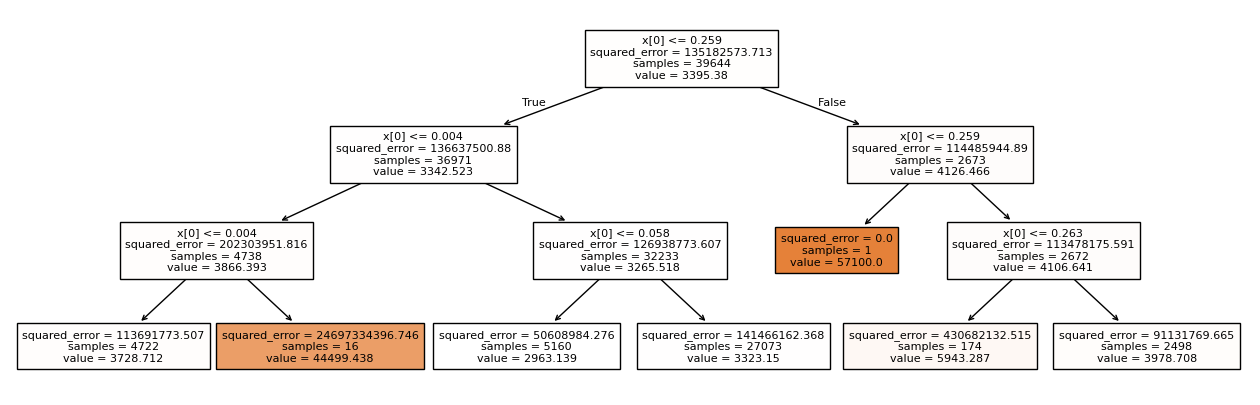

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))
plot_tree(dtregressor, filled=True, fontsize=8)
plt.savefig('decisiontree.png')
plt.show()


the resulting tree should show bianry splits on the sentiment feature and predicted share values in terminal nodes the chapter uses this to explain why decision trees are often more interpretable than other models

9. Measuring prefiction accuracy

In [15]:
allprediction = regressor.predict(np.array(allsentiment).reshape(-1, 1)).reshape(-1)
predictionerror = abs(allprediction - np.array(allshares))
print(np.mean(predictionerror))

3204.666231024562


this computes mean absolte error the lower the better

10. Train and test split with random forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

x = np.array(allsentiment).reshape(-1, 1)
y = np.array(allshares)

trainingx, testx, trainingy, testy = train_test_split(x, y, random_state=1)

print(len(trainingx))
print(len(trainingy))
print(len(testx))
print(len(testy))

rfregressor = RandomForestRegressor(random_state=1)
rfregressor.fit(trainingx, trainingy)
predicted = rfregressor.predict(testx)
predictionerror = abs(predicted - testy)

print(np.mean(predictionerror))

29733
29733
9911
9911


the book shows training size 29733 test size 9911 random forest test MAE about 3816

11. train and test split with k-NN

In [ ]:
knnregressor = KNeighborsRegressor(n_neighbors=15)
knnregressor.fit(trainingx, trainingy)
predicted = knnregressor.predict(testx)
predictionerror = abs(predicted - testy)

print(np.mean(predictionerror))

the chapter says k-NN achieves a test MAE of about 3292 which is better than the random forest result

12 multivariate supervised learning

In [ ]:
x = news[[' global_sentiment_polarity', ' n_unique_tokens', ' n_non_stop_words']]
y = np.array(allshares)

trainingx, testx, trainingy, testy = train_test_split(x, y, random_state=1)

from sklearn.ensemble import RandomForestRegressor
rfregressor = RandomForestRegressor(random_state=1)
rfregressor.fit(trainingx, trainingy)
predicted = rfregressor.predict(testx)
predictionerror = abs(predicted - testy)

print(np.mean(predictionerror))

the book reports a multivariate randome forest MAE of 3474 which is better than the univariate random forest model

13. Classification instead of regression

In [ ]:
themedian = np.median(news[' shares'])
news['abovemedianshares'] = 1 * (news[' shares'] > themedian)

x = news[[' global_sentiment_polarity', ' n_unique_tokens', ' n_non_stop_words']]
y = np.array(news['abovemedianshares'])

from sklearn.neighbors import KNeighborsClassifier
knnclassifier = KNeighborsClassifier(n_neighbors=15)

trainingx, testx, trainingy, testy = train_test_split(x, y, random_state=1)
knnclassifier.fit(trainingx, trainingy)
predicted = knnclassifier.predict(testx)

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(testy, predicted))

the chapter has a confusion matrix of [[2703 2280] [2370 2558]] this is used to talk about true positives false positives false negatives and true negatives

In [ ]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(testy, predicted)
recall = recall_score(testy, predicted)

print(precision)
print(recall)

the chapter has precision about .53 and recall about .52 these are not that strong which supports the chapters point that prediction article popluarity isnt that hard

Conclusion: the main lesson in this chapter is that supervised learning means learning a fuction from features to a target.  different algorithms make different assumptions and test est performance helps decide which model is most useful.